# 1. Data Audit, Cleaning & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and read files
df_history = pd.read_csv('TCS_stock_history.csv')
df_action = pd.read_csv('TCS_stock_action.csv')
df_info = pd.read_csv('TCS_stock_info - Sheet2.csv')

In [3]:
df_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


In [4]:
df_action.head()

,Date,Dividends,Stock Splits
0,2004-10-28,0.3750,0.0
1,2005-02-03,0.4375,0.0
2,2005-07-06,0.6250,0.0
3,2005-08-18,0.3750,0.0
4,2005-10-18,0.3750,0.0


In [5]:
df_info.head()

,zip,sector,fullTimeEmployees,longBusinessSummary,city,phone,country,companyOfficers,website,maxAge,...,fromCurrency,fiveYearAvgDividendYield,fiftyTwoWeekLow,bid,tradeable,dividendYield,bidSize,dayHigh,regularMarketPrice,logo_url
0,400001,Technology,509058,Tata Consultancy Services Limited provides inf...,Mumbai,91 22 6778 9999,India,[],http://www.tcs.com,1,...,NaN,1.47,2492.3,3771.45,False,0.0105,0,3805,3773.2,https://logo.clearbit.com/tcs.com


In [6]:
# Total rows and columns in each dataset
(df_history.shape), (df_action.shape), (df_info.shape)

((4463, 8), (70, 3), (1, 151))

In [7]:
# Checking for missing values
df_history.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [8]:
df_action.isnull().sum()

Date            0
Dividends       0
Stock Splits    0
dtype: int64

In [9]:
# Checking for duplicates
print("Number of duplicate rows:", df_history.duplicated().sum())

Number of duplicate rows: 0


In [10]:
print("Number of duplicate rows:", df_action.duplicated().sum())

Number of duplicate rows: 0


In [11]:
# Basic info
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


In [12]:
df_action.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          70 non-null     object 
 1   Dividends     70 non-null     float64
 2   Stock Splits  70 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.8+ KB


In [13]:
# Basic Statistics about the data
df_history.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,4463.000000,4463.000000,4463.000000,4463.000000,4.463000e+03,4463.000000,4463.000000
mean,866.936239,876.675013,856.653850,866.537398,3.537876e+06,0.071533,0.001344
std,829.905368,838.267104,821.233477,829.611313,3.273531e+06,0.965401,0.051842
min,24.146938,27.102587,24.146938,26.377609,0.000000e+00,0.000000,0.000000
25%,188.951782,191.571816,185.979417,188.594620,1.860959e+06,0.000000,0.000000
50%,530.907530,534.751639,525.616849,529.713257,2.757742e+06,0.000000,0.000000
75%,1156.462421,1165.815854,1143.622800,1154.784851,4.278625e+06,0.000000,0.000000
max,3930.000000,3981.750000,3892.100098,3954.550049,8.806715e+07,40.000000,2.000000


- The average stock prices (Open, High, Low, Close) are around 866–877, with a large spread, indicating significant fluctuations.
- The minimum stock price is very low (around 24), while the maximum is very high (around 3930), showing large volatility.
- The average trading volume is about 3.5 million, with a large standard deviation, meaning there are times of both high and low trading activity.
- Dividends are mostly 0, with a very small average dividend of 0.0715. Some high dividend payouts (up to 40) are possible but rare.
- Stock splits are infrequent, with most entries showing a value of 0, and the maximum recorded split is 2.

In [14]:
df_action.describe()

,Dividends,Stock Splits
count,70.000000,70.000000
mean,4.560714,0.085714
std,6.284794,0.407995
min,0.375000,0.000000
25%,1.000000,0.000000
50%,2.500000,0.000000
75%,5.000000,0.000000
max,40.000000,2.000000


In [15]:
# Convert the 'Date' column to datetime format and sort the dataset by date to ensure the data is in proper chronological order for time series analysis
df_history['Date'] = pd.to_datetime(df_history['Date'])
df_history.sort_values(by = 'Date', inplace = True)
df_history.info()
df_history.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          4463 non-null   datetime64[ns]
 1   Open          4463 non-null   float64       
 2   High          4463 non-null   float64       
 3   Low           4463 non-null   float64       
 4   Close         4463 non-null   float64       
 5   Volume        4463 non-null   int64         
 6   Dividends     4463 non-null   float64       
 7   Stock Splits  4463 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 279.1 KB


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


In [16]:
df_action['Date'] = pd.to_datetime(df_action['Date'])
df_action.sort_values(by = 'Date', inplace = True)
df_action.info()
df_action.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          70 non-null     datetime64[ns]
 1   Dividends     70 non-null     float64       
 2   Stock Splits  70 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.8 KB


,Date,Dividends,Stock Splits
0,2004-10-28,0.3750,0.0
1,2005-02-03,0.4375,0.0
2,2005-07-06,0.6250,0.0
3,2005-08-18,0.3750,0.0
4,2005-10-18,0.3750,0.0


In [17]:
# Convert 'Open', 'Close', 'High', and 'Low' columns to numeric values.
df_history['Open'] = pd.to_numeric(df_history['Open'], errors = 'coerce')
df_history['Close'] = pd.to_numeric(df_history['Close'], errors = 'coerce')
df_history['High'] = pd.to_numeric(df_history['High'], errors = 'coerce')
df_history['Low'] = pd.to_numeric(df_history['Low'], errors = 'coerce')

In [18]:
# Extracting essential features from the Date column
df_history['year'] = df_history['Date'].dt.year
df_history['month'] = df_history['Date'].dt.month
df_history['Dayofweek'] = df_history['Date'].dt.dayofweek
df_history['Quarter'] = df_history['Date'].dt.quarter
df_history['IsMonthStart'] = df_history['Date'].dt.is_month_start
df_history['IsMonthEnd'] = df_history['Date'].dt.is_month_end
df_history['IsQuarterStart'] = df_history['Date'].dt.is_quarter_start
df_history['IsQuarterEnd'] = df_history['Date'].dt.is_quarter_end

df_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,Dayofweek,Quarter,IsMonthStart,IsMonthEnd,IsQuarterStart,IsQuarterEnd
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0,2002,8,0,3,False,False,False,False
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,2002,8,1,3,False,False,False,False
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,2002,8,2,3,False,False,False,False
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,2002,8,3,3,False,False,False,False
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,2002,8,4,3,False,False,False,False


In [19]:
# Checking all the datatypes once again
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4463 non-null   datetime64[ns]
 1   Open            4463 non-null   float64       
 2   High            4463 non-null   float64       
 3   Low             4463 non-null   float64       
 4   Close           4463 non-null   float64       
 5   Volume          4463 non-null   int64         
 6   Dividends       4463 non-null   float64       
 7   Stock Splits    4463 non-null   float64       
 8   year            4463 non-null   int32         
 9   month           4463 non-null   int32         
 10  Dayofweek       4463 non-null   int32         
 11  Quarter         4463 non-null   int32         
 12  IsMonthStart    4463 non-null   bool          
 13  IsMonthEnd      4463 non-null   bool          
 14  IsQuarterStart  4463 non-null   bool          
 15  IsQu

# 2. Exploratory Data Analysis (EDA)

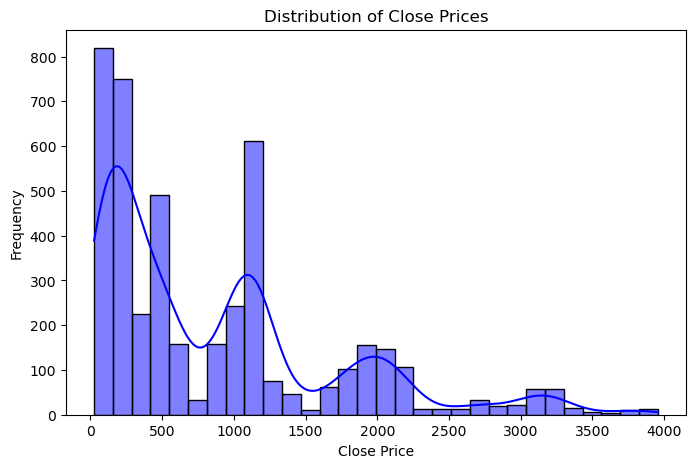

In [20]:
plt.figure(figsize = (8,5))
sns.histplot(df_history['Close'], bins = 30, kde = True, color = 'blue')
plt.title("Distribution of Close Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

- The distribution is highly skewed to the right (positively skewed), meaning most trading days occurred when the stock price was low.

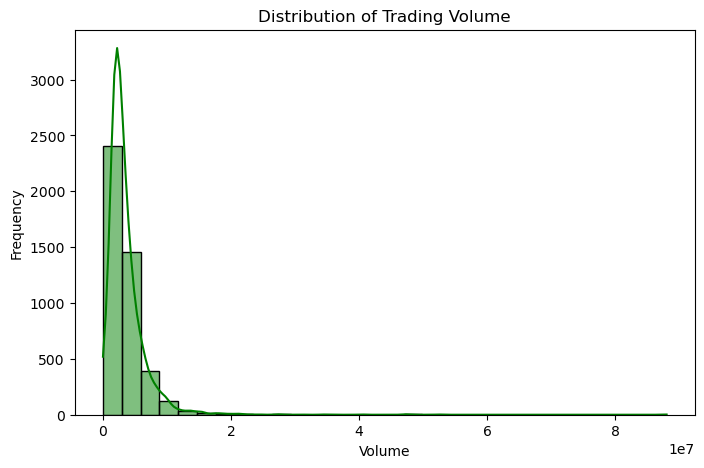

In [21]:
plt.figure(figsize = (8,5))
sns.histplot(df_history['Volume'], bins = 30, kde = True, color = 'green')
plt.title("Distribution of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()


- The distribution is heavily skewed to the right, confirming that most trading days occur with very low volume. High volume days are rare but represent significant market activity.
- The tallest bar is at the extreme left (low volume), indicating that the stock typically trades in a quiet, routine manner.
- The presence of a long, thin tail on the right side of the distribution represents massive volume spikes (outliers).

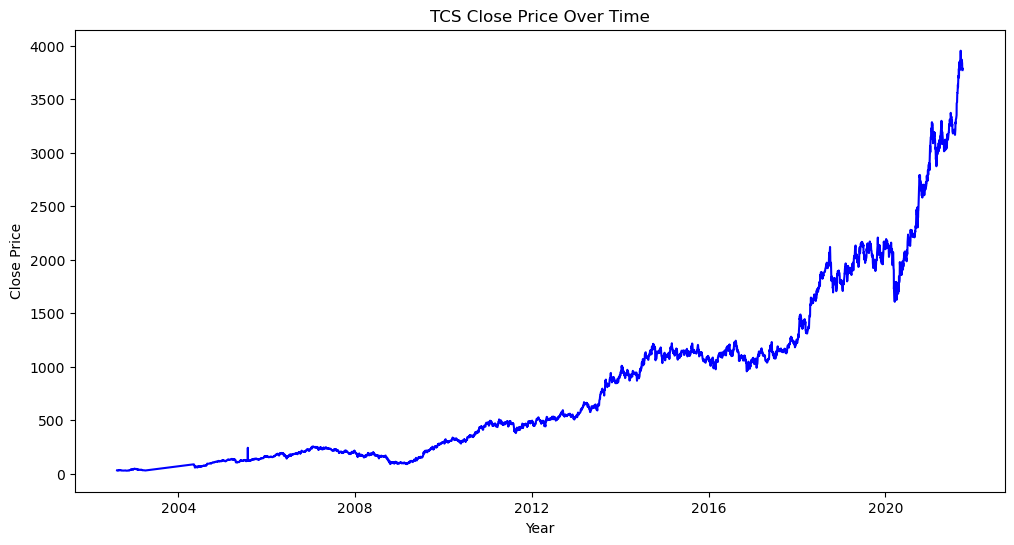

In [22]:
plt.figure(figsize = (12,6))
plt.plot(df_history['Date'], df_history['Close'], color = 'blue')
plt.title("TCS Close Price Over Time")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()


- The stock exhibits a clear, powerful upward trend over the entire period (2002-2021). The price increase accelerates significantly in the later years (post 2015).

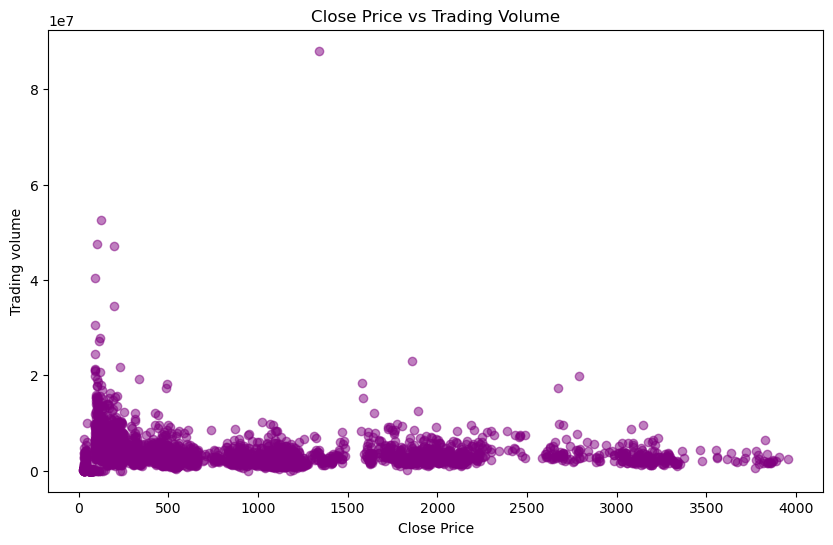

In [23]:
plt.figure(figsize = (10,6))
plt.scatter(y = df_history['Volume'], x = df_history['Close'], alpha = 0.5, color = 'purple')
plt.title("Close Price vs Trading Volume")
plt.xlabel("Close Price")
plt.ylabel("Trading volume")
plt.show()


- Trading volume is more concentrated at lower close prices, suggesting that as the price increases, fewer shares are traded.
- Most of the data points are concentrated on the lower end of the close price scale.
- High trading volumes tend to occur when the close price is relatively low, possibly due to investor behavior.

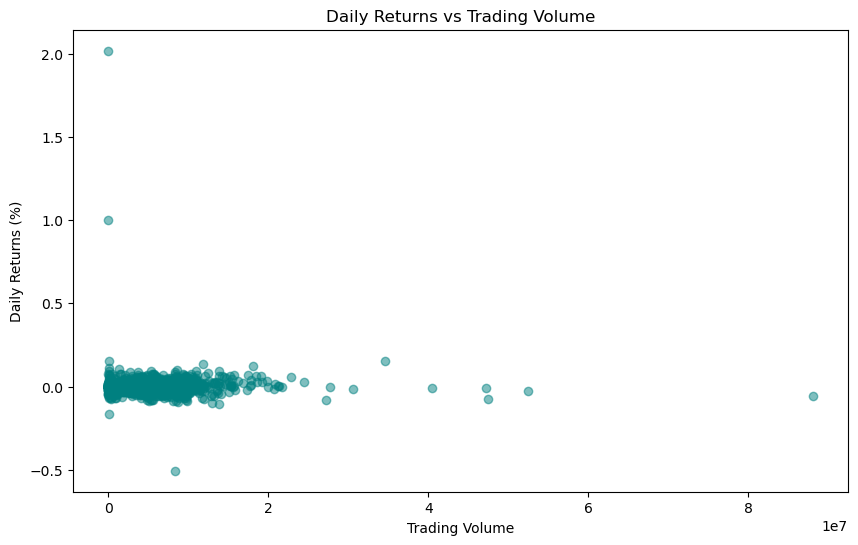

In [24]:
df_history['Return'] = df_history['Close'].pct_change()

plt.figure(figsize = (10,6))
plt.scatter(df_history['Volume'], df_history['Return'], alpha = 0.5, color = 'teal')
plt.title("Daily Returns vs Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Daily Returns (%)")
plt.show()


- The data points form a wide, dispersed cloud centered around 0% return, indicating a very weak direct linear correlation between the volume traded and the magnitude of the daily return.
-  For the majority of days (low-to-moderate volume), the returns are symmetrically distributed around 0%. This shows that low volume days are not inherently biased towards positive or negative returns.

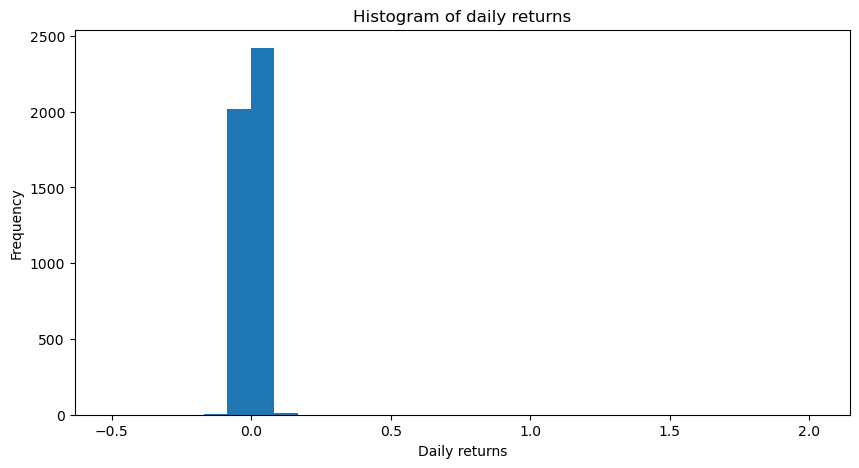

In [25]:
plt.figure(figsize=(10,5))
plt.hist(df_history['Return'].dropna(), bins=30)
plt.title("Histogram of daily returns")
plt.xlabel('Daily returns')
plt.ylabel('Frequency')
plt.show()

- The distribution of daily returns is tightly centered around zero. The returns look approximately normally distributed.
- The histogram shows a peak around zero and fewer bars as the returns increase or decrease.

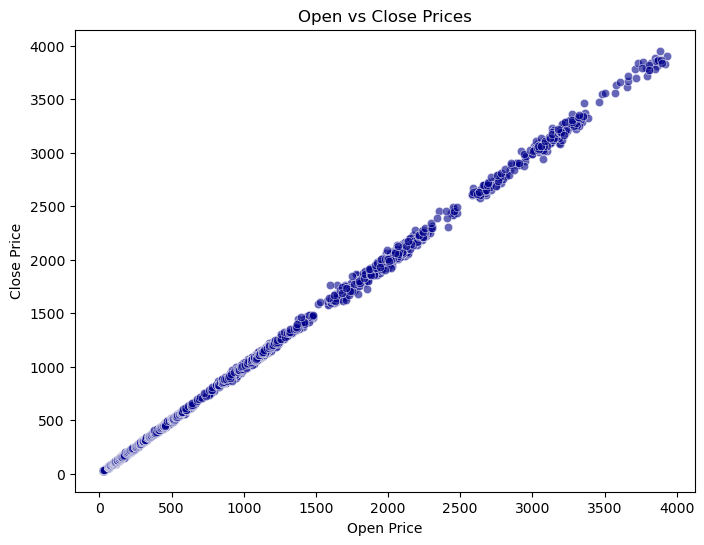

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_history['Open'], y=df_history['Close'], alpha=0.6, color='darkblue')
plt.title("Open vs Close Prices")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()


- The data points form a tight, straight line showing tht the stock's closing price is almost always very close to its opening price.
- Most days show very little price movement (Close−Open is small), as the points rarely deviate far from the central diagonal line. This highlights the stock's low daily volatility.

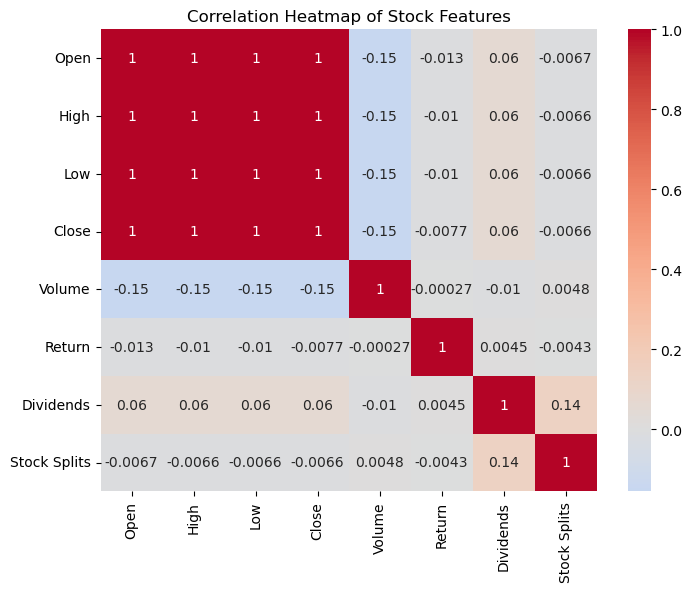

In [27]:
plt.figure(figsize = (8,6))
corr = df_history[['Open','High','Low','Close','Volume','Return','Dividends','Stock Splits']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Stock Features")
plt.show()


- Open, High, Low, and Close prices are highly positively correlated (correlation = 1), showing they move together.
- Volume has a slightly negative correlation with price features, meaning higher prices don’t always mean higher trading volume.
- Return, Dividends, and Stock Splits show very weak correlations with other variables, suggesting they are mostly independent.

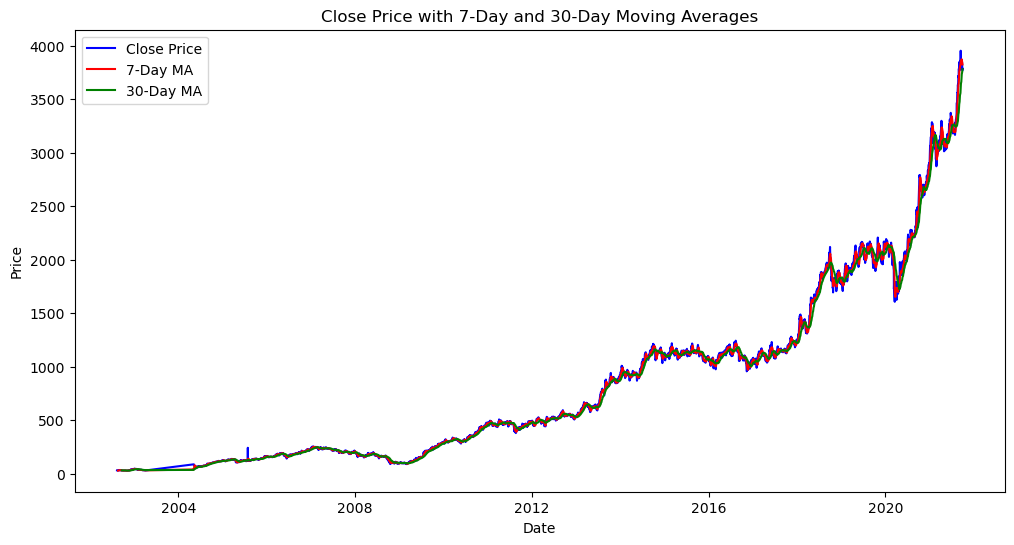

In [28]:
df_history['MA7'] = df_history['Close'].rolling(window = 7).mean()
df_history['MA30'] = df_history['Close'].rolling(window = 30).mean()

plt.figure(figsize=(12,6))
plt.plot(df_history['Date'], df_history['Close'], label = 'Close Price', color='blue')
plt.plot(df_history['Date'], df_history['MA7'], label = '7-Day MA', color='red')
plt.plot(df_history['Date'], df_history['MA30'], label = '30-Day MA', color='green')
plt.title("Close Price with 7-Day and 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


- The stock's closing price shows long-term growth over the years with short-term fluctuations.
- Both moving averages (7-day and 30-day) follow the same trend, with the 7-day being more sensitive to short-term movements.
- The lines move closely together, confirming a strong overall upward trend.

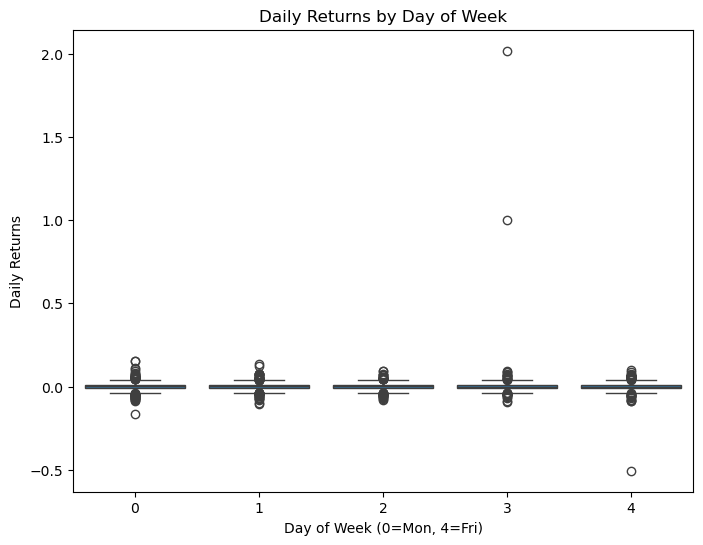

In [29]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df_history['Dayofweek'], y=df_history['Return'])
plt.title("Daily Returns by Day of Week")
plt.xlabel("Day of Week (0=Mon, 4=Fri)")
plt.ylabel("Daily Returns")
plt.show()


- The daily returns across all weekdays (Monday–Friday) are almost similar, with no major differences in their distribution.
- A few outliers are present on certain days, showing occasional large returns or losses.

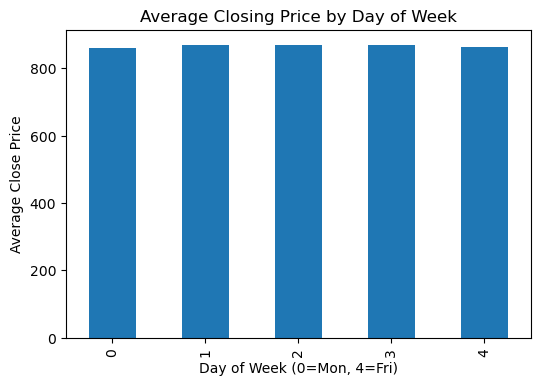

In [30]:
avg_by_day = df_history.groupby('Dayofweek')['Close'].mean()

avg_by_day.plot(kind='bar', figsize=(6,4))
plt.title("Average Closing Price by Day of Week")
plt.xlabel("Day of Week (0=Mon, 4=Fri)")
plt.ylabel("Average Close Price")
plt.show()


- No Day of Week Effect: The mean prices for Monday through Friday are almost identical.

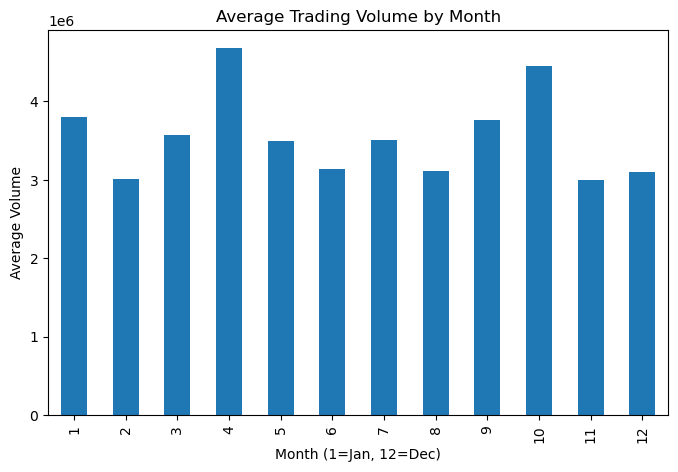

In [31]:
avg_by_month = df_history.groupby('month')['Volume'].mean()

avg_by_month.plot(kind='bar', figsize=(8,5))
plt.title("Average Trading Volume by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Average Volume")
plt.show()


- The chart indicates that trading volume is relatively stable, with a slight increase in certain months.
- October (Month 10) shows the highest average trading volume, while December (Month 12) shows the lowest.
- The months from January through October exhibit consistent volume, with small peaks in January, March, April, and September.

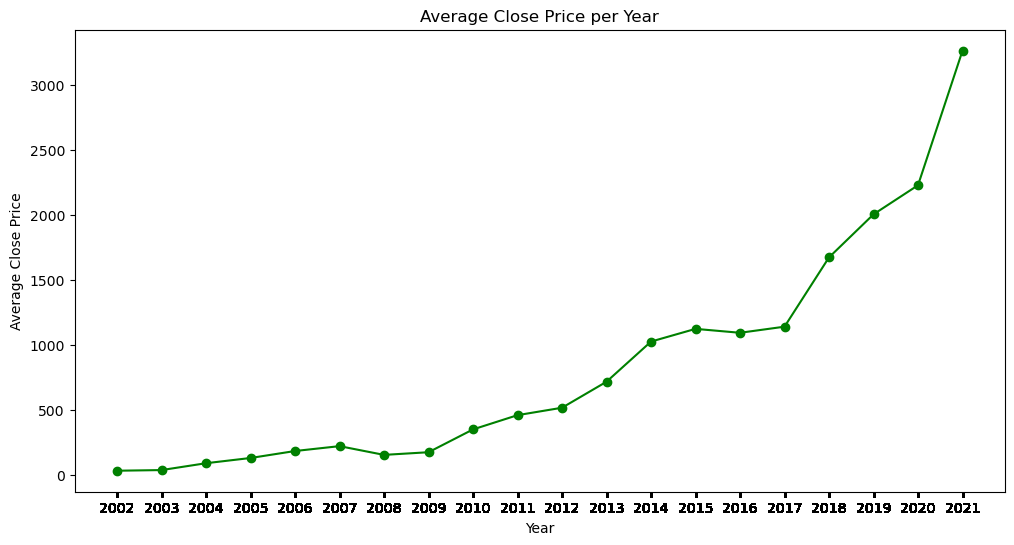

In [32]:
plt.figure(figsize=(12,6))
df_history.groupby('year')['Close'].mean().plot(kind='line', marker='o', color='green')
plt.title("Average Close Price per Year")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.xticks(df_history['year'].astype(int))  

plt.show()


-  The mean price for each year shows a clear, consistent, and strong yearly step-up in value.

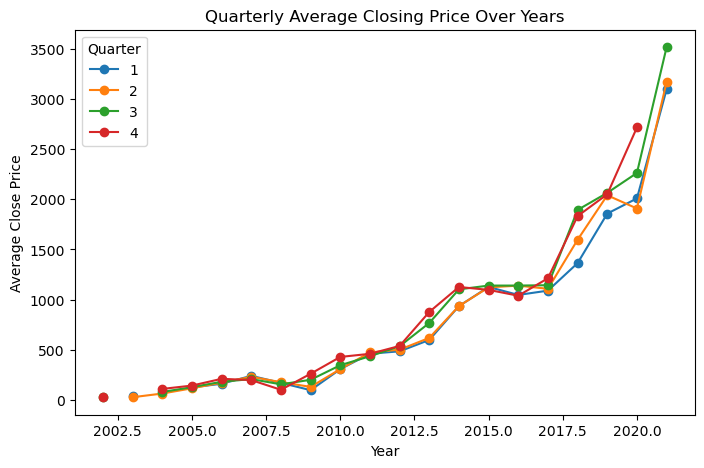

In [33]:
avg_by_quarter = df_history.groupby(['year','Quarter'])['Close'].mean().unstack()

avg_by_quarter.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Quarterly Average Closing Price Over Years")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.show()


- Over the years, all quarters have shown significant growth, but Quarter 4 (red) consistently leads with the highest closing price.
- Quarters 1 (blue) and 2 (orange) experienced slower growth, especially in the early years.
- Quarter 3 (green) follows a similar trend to Q4 but does not experience the sharp rise seen post-2017.
- The overall market trend shows substantial growth in recent years, particularly from 2017 onward.

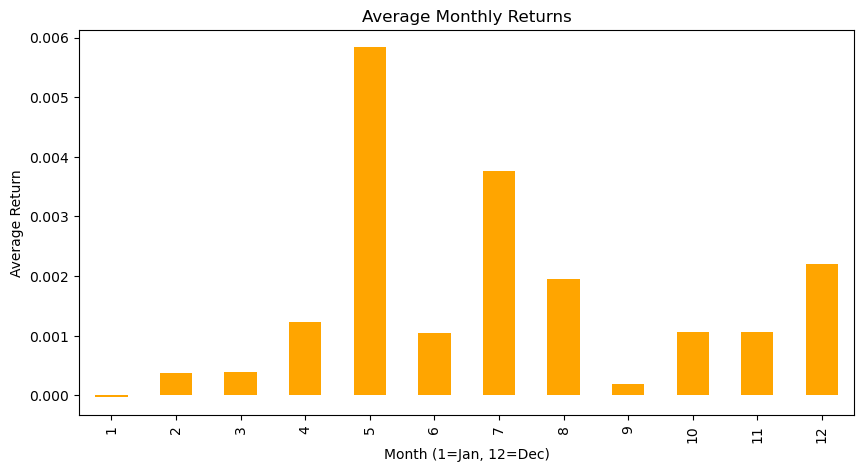

In [34]:
plt.figure(figsize=(10,5))
df_history.groupby('month')['Return'].mean().plot(kind='bar', color='orange')
plt.title("Average Monthly Returns")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Average Return")
plt.show()

- The chart shows monthly returns with a clear peak in May (Month 5), where the return significantly surpasses other months.
- The majority of months have average returns close to zero, with small fluctuations in April, July, and December.
- May is the standout month, reflecting unusually high returns compared to the rest.

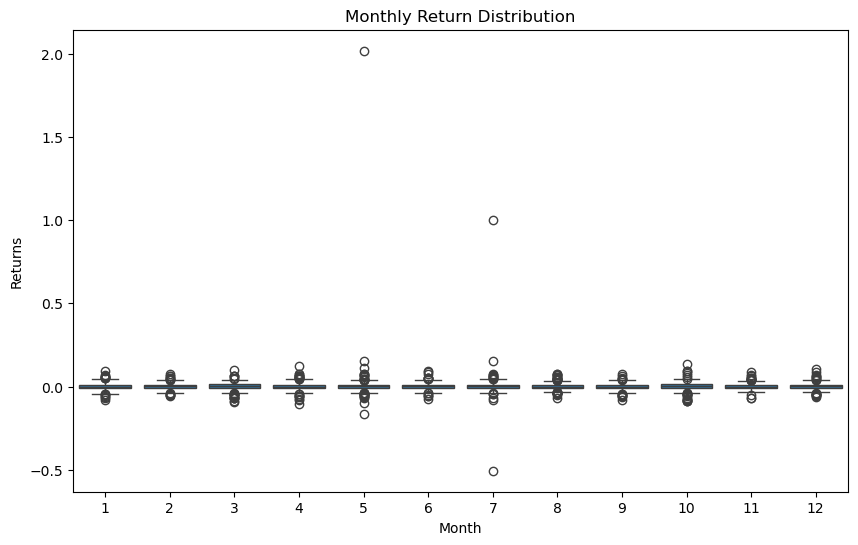

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(x='month', y='Return', data=df_history)
plt.title("Monthly Return Distribution")
plt.xlabel("Month")
plt.ylabel("Returns")
plt.show()


- The monthly return distribution shows that returns are generally near zero across all months, with minor fluctuations.
- There is a consistent pattern of minimal returns each month, with occasional outliers.
- This indicates that returns are fairly stable throughout the year, with no significant month-to-month variations.

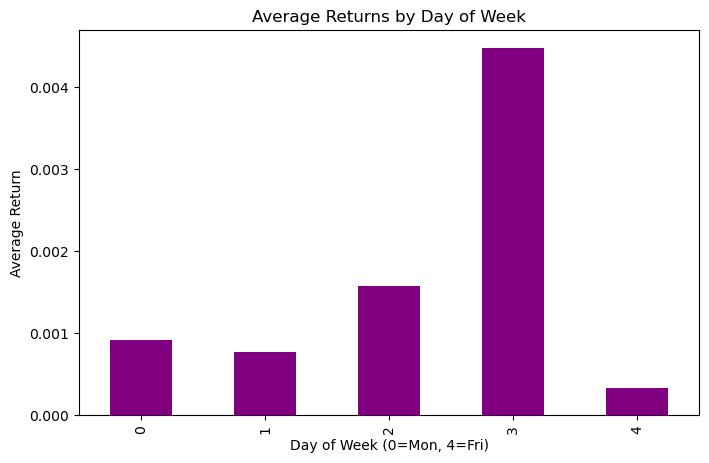

In [36]:
plt.figure(figsize=(8,5))
df_history.groupby('Dayofweek')['Return'].mean().plot(kind='bar', color='purple')
plt.title("Average Returns by Day of Week")
plt.xlabel("Day of Week (0=Mon, 4=Fri)")
plt.ylabel("Average Return")
plt.show()


- Thursday (3) has a significant spike in average returns compared to other days, suggesting that it tends to have higher returns.

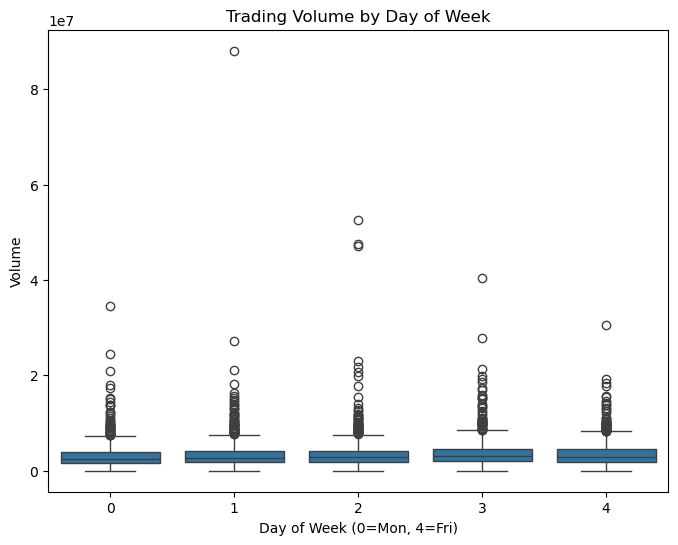

In [37]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Dayofweek', y='Volume', data=df_history)
plt.title("Trading Volume by Day of Week")
plt.xlabel("Day of Week (0=Mon, 4=Fri)")
plt.ylabel("Volume")
plt.show()


- The trading volume shows consistent fluctuations across days, with Monday (0) and Thursday (3) having the highest outliers.
- Volume is relatively low throughout the week, with a few extreme values that indicate higher trading on certain days.
- The data shows that the trading volume doesn’t significantly differ between days of the week.

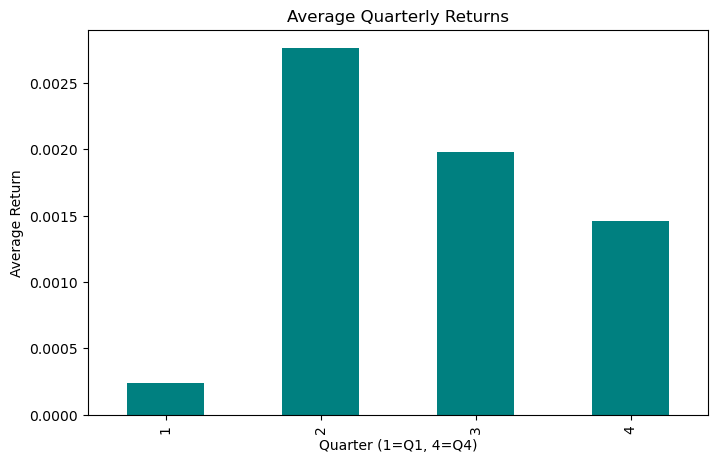

In [38]:
plt.figure(figsize=(8,5))
df_history.groupby('Quarter')['Return'].mean().plot(kind='bar', color='teal')
plt.title("Average Quarterly Returns")
plt.xlabel("Quarter (1=Q1, 4=Q4)")
plt.ylabel("Average Return")
plt.show()


- Q2 has a significant spike in average return compared to the other quarters, while Q1 has a very low value.
- Q4 and Q3 show moderate returns, with Q3 performing slightly better than Q4.

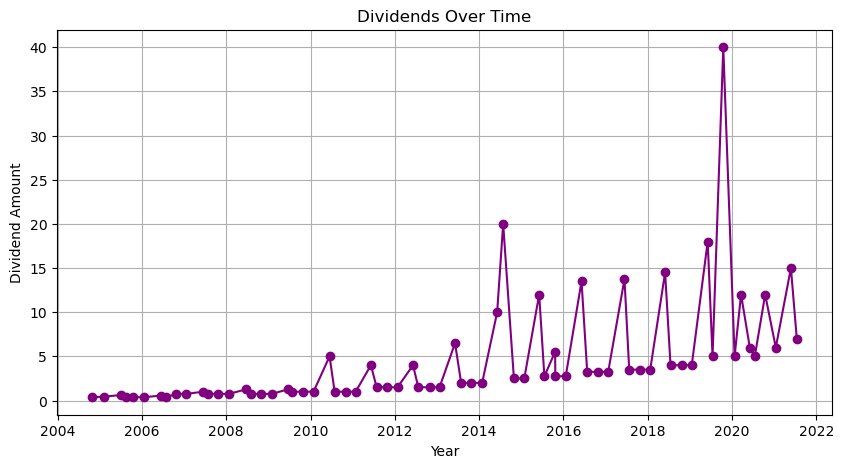

In [39]:
plt.figure(figsize=(10,5))
plt.plot(df_action['Date'], df_action['Dividends'], marker='o', color='purple')
plt.title("Dividends Over Time")
plt.xlabel("Year")
plt.ylabel("Dividend Amount")
plt.grid(True)
plt.show()


- The dividend amounts were low and relatively stable from 2004 to 2013.
- In 2014, there is a sharp increase in dividends, with a noticeable spike.
- After 2014, the dividends continue to rise but with some fluctuations.
- A major peak in dividends occurs in 2020, followed by a decrease in 2021 and 2022.
- The overall trend suggests gradual growth, but with some irregular spikes and dips.

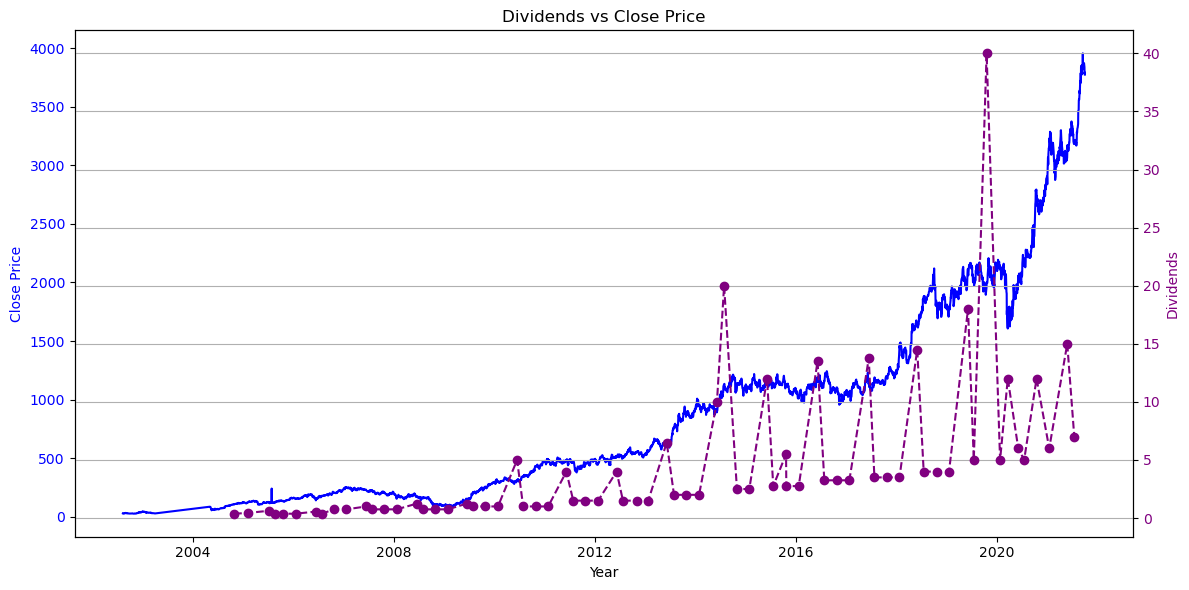

In [40]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot Close price
ax1.plot(df_history['Date'], df_history['Close'], color='blue', label='Close Price')
ax1.set_xlabel("Year")
ax1.set_ylabel("Close Price", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis for Dividends
ax2 = ax1.twinx()
ax2.plot(df_action['Date'], df_action['Dividends'], color='purple', marker='o', linestyle='--', label='Dividends')
ax2.set_ylabel("Dividends", color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

plt.title("Dividends vs Close Price")
plt.grid(True)
fig.tight_layout()
plt.show()


- The chart compares closing stock price (blue) with dividend payouts (purple).
- The dividends paid by the company are not consistent and are often small, except for a few sharp peaks in certain years (2010, 2018, and 2020).
- The stock’s price generally rises, but the dividends do not directly correspond to this rise. The biggest dividends were paid in years when the stock price also surged (2020).
- Despite the stock price increase, dividends show a more irregular pattern, suggesting the company may not focus on regular payouts but rather on strategic dividend increases.

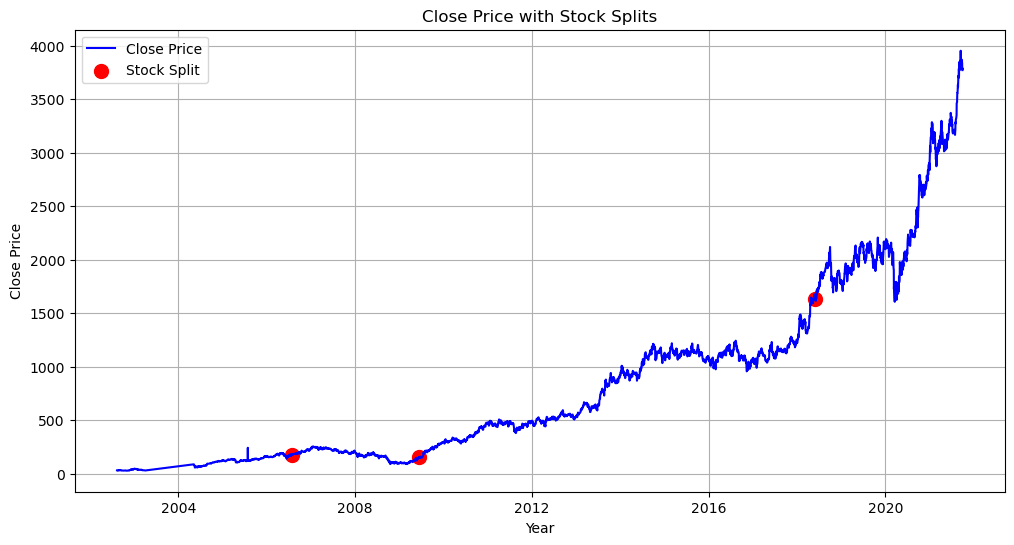

In [41]:
plt.figure(figsize=(12,6))

# Plot Close price
plt.plot(df_history['Date'], df_history['Close'], color='blue', label='Close Price')

# Mark Stock Split dates
splits = df_action[df_action['Stock Splits'] > 0]   # only rows where a split happened
plt.scatter(splits['Date'], df_history.set_index('Date').loc[splits['Date'], 'Close'],
            color='red', marker='o', s=100, label='Stock Split')

plt.title("Close Price with Stock Splits")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


- The blue line shows TCS’s closing stock price trend over time, with red dots marking stock split events.
- The stock splits occur at specific points (around 2005, 2014, and 2020). After each split, there is a noticeable increase in the stock price, though the stock price adjusts downward after the split.
- After every split, the stock price kept increasing, which means splits didn’t hurt growth.
- Splits just made the stock cheaper per share, so more investors could buy it.
- Overall, the stock shows a strong long-term upward trend with only small dips in between.

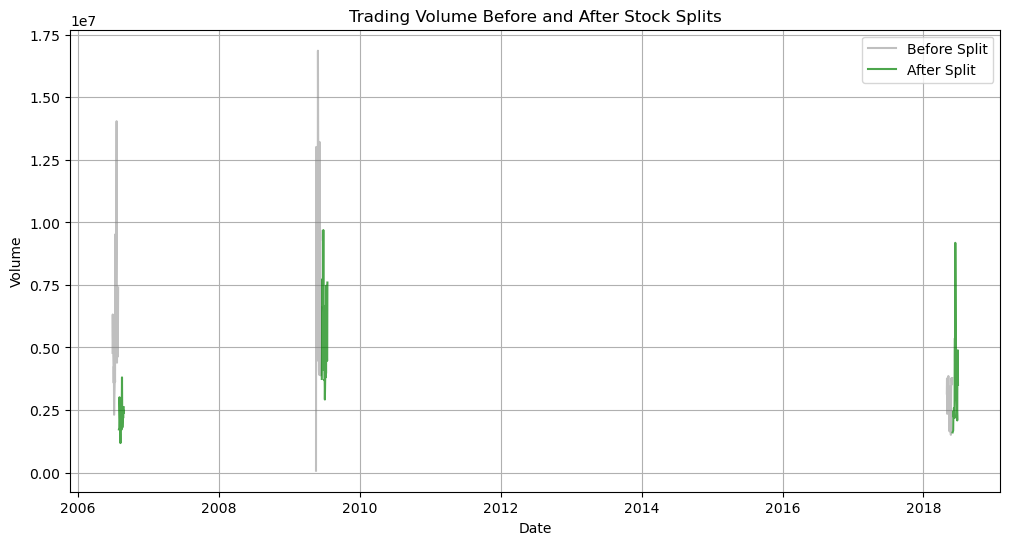

In [42]:
plt.figure(figsize=(12,6))

for _, row in splits.iterrows():
    split_date = row['Date']
    before = df_history[(df_history['Date'] >= split_date - pd.Timedelta(days=30)) &
                        (df_history['Date'] < split_date)]
    after = df_history[(df_history['Date'] > split_date) &
                       (df_history['Date'] <= split_date + pd.Timedelta(days=30))]

    plt.plot(before['Date'], before['Volume'], color='gray', alpha=0.5, label='Before Split' if _ == splits.index[0] else "")
    plt.plot(after['Date'], after['Volume'], color='green', alpha=0.7, label='After Split' if _ == splits.index[0] else "")

plt.title("Trading Volume Before and After Stock Splits")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()


- There is a noticeable spike in trading activity immediately around stock split events.
- After the splits, trading volume tends to stabilize but remains active, showing that stock splits attract investor attention and liquidity.
- Overall, splits appear to temporarily increase market participation.

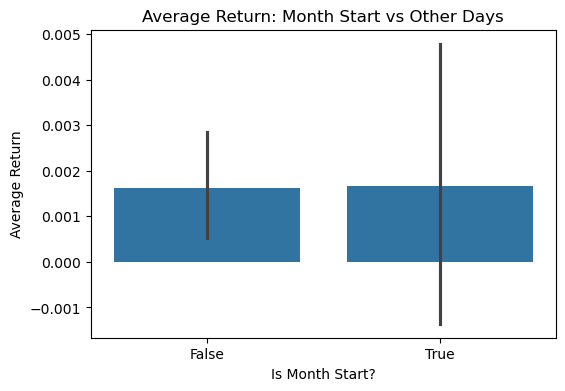

In [43]:
plt.figure(figsize=(6,4))
sns.barplot(x='IsMonthStart', y='Return', data=df_history, estimator=np.mean)
plt.title("Average Return: Month Start vs Other Days")
plt.xlabel("Is Month Start?")
plt.ylabel("Average Return")
plt.show()

- Returns are slightly higher at the beginning of the month compared to other days.

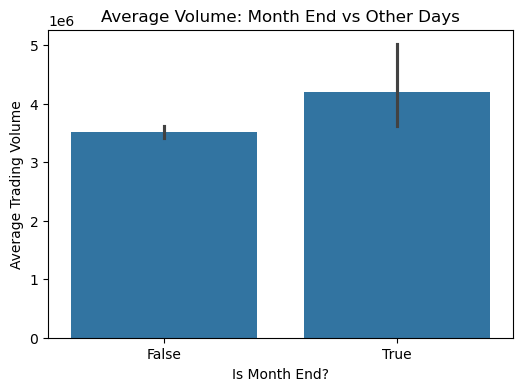

In [44]:
plt.figure(figsize=(6,4))
sns.barplot(x='IsMonthEnd', y='Volume', data=df_history, estimator=np.mean)
plt.title("Average Volume: Month End vs Other Days")
plt.xlabel("Is Month End?")
plt.ylabel("Average Trading Volume")
plt.show()


- At the end of the month, the average trading volume spikes compared to other days.

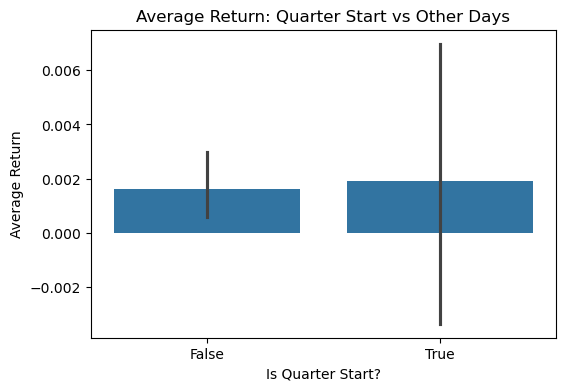

In [45]:
plt.figure(figsize=(6,4))
sns.barplot(x='IsQuarterStart', y='Return', data=df_history, estimator=np.mean)
plt.title("Average Return: Quarter Start vs Other Days")
plt.xlabel("Is Quarter Start?")
plt.ylabel("Average Return")
plt.show()


- Similar to the quarter end, returns at the start of the quarter are higher than on other days.

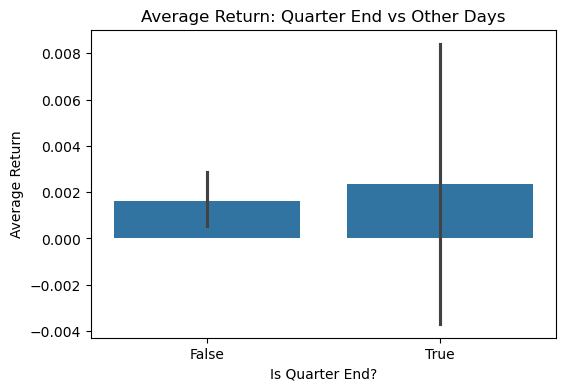

In [46]:
plt.figure(figsize=(6,4))
sns.barplot(x='IsQuarterEnd', y='Return', data=df_history, estimator=np.mean)
plt.title("Average Return: Quarter End vs Other Days")
plt.xlabel("Is Quarter End?")
plt.ylabel("Average Return")
plt.show()


- On quarter-end days, the average return is significantly higher than on other days.
- The variability in return is also higher at quarter ends, as reflected by the larger spread (whiskers).

# 3. Feature Engineering

In [47]:
df_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,Dayofweek,Quarter,IsMonthStart,IsMonthEnd,IsQuarterStart,IsQuarterEnd,Return,MA7,MA30
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0,2002,8,0,3,False,False,False,False,NaN,NaN,NaN
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,2002,8,1,3,False,False,False,False,-0.013539,NaN,NaN
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,2002,8,2,3,False,False,False,False,-0.068944,NaN,NaN
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,2002,8,3,3,False,False,False,False,0.000000,NaN,NaN
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,2002,8,4,3,False,False,False,False,-0.002400,NaN,NaN


In [48]:
# Create lag features of Close price
lag_days = [1, 2, 3, 5, 7, 14, 21]

for lag in lag_days:
    df_history[f'Close_lag{lag}'] = df_history['Close'].shift(lag)

df_history.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,...,Return,MA7,MA30,Close_lag1,Close_lag2,Close_lag3,Close_lag5,Close_lag7,Close_lag14,Close_lag21
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0,2002,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,2002,8,...,-0.013539,NaN,NaN,29.519140,NaN,NaN,NaN,NaN,NaN,NaN
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,2002,8,...,-0.068944,NaN,NaN,29.119476,29.519140,NaN,NaN,NaN,NaN,NaN
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,2002,8,...,0.000000,NaN,NaN,27.111877,29.119476,29.519140,NaN,NaN,NaN,NaN
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,2002,8,...,-0.002400,NaN,NaN,27.111877,27.111877,29.119476,NaN,NaN,NaN,NaN
5,2002-08-19,27.269876,27.269876,26.126661,26.377609,205880,0.0,0.0,2002,8,...,-0.024742,NaN,NaN,27.046812,27.111877,27.111877,29.519140,NaN,NaN,NaN
6,2002-08-20,26.563503,28.794168,26.386910,27.111877,3773624,0.0,0.0,2002,8,...,0.027837,27.628381,NaN,26.377609,27.046812,27.111877,29.119476,NaN,NaN,NaN
7,2002-08-21,28.608262,29.147341,27.158333,28.440964,3011064,0.0,0.0,2002,8,...,0.049022,27.474356,NaN,27.111877,26.377609,27.046812,27.111877,29.519140,NaN,NaN
8,2002-08-22,29.379720,30.913303,29.231009,29.667849,6732480,0.0,0.0,2002,8,...,0.043138,27.552695,NaN,28.440964,27.111877,26.377609,27.111877,29.119476,NaN,NaN
9,2002-08-23,29.928077,32.437575,29.565595,31.452364,4841672,0.0,0.0,2002,8,...,0.060150,28.172765,NaN,29.667849,28.440964,27.111877,27.046812,27.111877,NaN,NaN


In [49]:
df_history.isnull().sum()

Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
Dividends          0
Stock Splits       0
year               0
month              0
Dayofweek          0
Quarter            0
IsMonthStart       0
IsMonthEnd         0
IsQuarterStart     0
IsQuarterEnd       0
Return             1
MA7                6
MA30              29
Close_lag1         1
Close_lag2         2
Close_lag3         3
Close_lag5         5
Close_lag7         7
Close_lag14       14
Close_lag21       21
dtype: int64

In [50]:
# Filling missing values in Lag columns
lag_cols = [col for col in df_history.columns if 'lag' in col]   # finds all columns having the word 'lag'
df_history[lag_cols] = df_history[lag_cols].fillna(method='bfill')

# Filling missing values in rolling average columns
rolling_cols = [col for col in df_history.columns if 'MA' in col]
df_history[rolling_cols] = df_history[rolling_cols].fillna(method='bfill')

# Fill missing values in Return column
df_history['Return'] = df_history['Return'].fillna(0)

In [51]:
df_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,year,month,...,Return,MA7,MA30,Close_lag1,Close_lag2,Close_lag3,Close_lag5,Close_lag7,Close_lag14,Close_lag21
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0,2002,8,...,0.000000,27.628381,30.050465,29.519140,29.519140,29.519140,29.51914,29.51914,29.51914,29.51914
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,2002,8,...,-0.013539,27.628381,30.050465,29.519140,29.519140,29.519140,29.51914,29.51914,29.51914,29.51914
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,2002,8,...,-0.068944,27.628381,30.050465,29.119476,29.519140,29.519140,29.51914,29.51914,29.51914,29.51914
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,2002,8,...,0.000000,27.628381,30.050465,27.111877,29.119476,29.519140,29.51914,29.51914,29.51914,29.51914
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,2002,8,...,-0.002400,27.628381,30.050465,27.111877,27.111877,29.119476,29.51914,29.51914,29.51914,29.51914


In [52]:
df_history.isnull().sum()

Date              0
Open              0
High              0
Low               0
Close             0
Volume            0
Dividends         0
Stock Splits      0
year              0
month             0
Dayofweek         0
Quarter           0
IsMonthStart      0
IsMonthEnd        0
IsQuarterStart    0
IsQuarterEnd      0
Return            0
MA7               0
MA30              0
Close_lag1        0
Close_lag2        0
Close_lag3        0
Close_lag5        0
Close_lag7        0
Close_lag14       0
Close_lag21       0
dtype: int64

In [53]:
cols_to_drop = ['Date', 'Dividends', 'Stock Splits', 'IsMonthStart', 'IsMonthEnd',  'IsQuarterStart', 'IsQuarterEnd']
df_history = df_history.drop(columns = cols_to_drop)

df_history.head(10)

,Open,High,Low,Close,Volume,year,month,Dayofweek,Quarter,Return,MA7,MA30,Close_lag1,Close_lag2,Close_lag3,Close_lag5,Close_lag7,Close_lag14,Close_lag21
0,28.794172,29.742206,28.794172,29.519140,212976,2002,8,0,3,0.000000,27.628381,30.050465,29.519140,29.519140,29.519140,29.519140,29.519140,29.51914,29.51914
1,29.556316,30.030333,28.905705,29.119476,153576,2002,8,1,3,-0.013539,27.628381,30.050465,29.519140,29.519140,29.519140,29.519140,29.519140,29.51914,29.51914
2,29.184536,29.184536,26.563503,27.111877,822776,2002,8,2,3,-0.068944,27.628381,30.050465,29.119476,29.519140,29.519140,29.519140,29.519140,29.51914,29.51914
3,27.111877,27.111877,27.111877,27.111877,0,2002,8,3,3,0.000000,27.628381,30.050465,27.111877,29.119476,29.519140,29.519140,29.519140,29.51914,29.51914
4,26.972458,28.255089,26.582090,27.046812,811856,2002,8,4,3,-0.002400,27.628381,30.050465,27.111877,27.111877,29.119476,29.519140,29.519140,29.51914,29.51914
5,27.269876,27.269876,26.126661,26.377609,205880,2002,8,0,3,-0.024742,27.628381,30.050465,27.046812,27.111877,27.111877,29.519140,29.519140,29.51914,29.51914
6,26.563503,28.794168,26.386910,27.111877,3773624,2002,8,1,3,0.027837,27.628381,30.050465,26.377609,27.046812,27.111877,29.119476,29.519140,29.51914,29.51914
7,28.608262,29.147341,27.158333,28.440964,3011064,2002,8,2,3,0.049022,27.474356,30.050465,27.111877,26.377609,27.046812,27.111877,29.519140,29.51914,29.51914
8,29.379720,30.913303,29.231009,29.667849,6732480,2002,8,3,3,0.043138,27.552695,30.050465,28.440964,27.111877,26.377609,27.111877,29.119476,29.51914,29.51914
9,29.928077,32.437575,29.565595,31.452364,4841672,2002,8,4,3,0.060150,28.172765,30.050465,29.667849,28.440964,27.111877,27.046812,27.111877,29.51914,29.51914


# 4. Predictive Modeling

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [55]:
 # Separate features (X) and target (y)
X = df_history.drop('Close', axis = 1)
y = df_history['Close']

In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

# Columns to scale
scale_cols = ['Open', 'High', 'Low', 'Volume', 'Return', 'MA7', 'MA30', 'Close_lag1', 'Close_lag2', 'Close_lag3',
              'Close_lag5', 'Close_lag7', 'Close_lag14', 'Close_lag21']

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = X_train.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])

# Transform the test data using the same scaler
X_test_scaled = X_test.copy()
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

X_train_scaled.head()



,Open,High,Low,Volume,year,month,Dayofweek,Quarter,Return,MA7,MA30,Close_lag1,Close_lag2,Close_lag3,Close_lag5,Close_lag7,Close_lag14,Close_lag21
0,-1.198111,-1.199583,-1.193522,-1.045547,2002,8,0,3,-0.038559,-1.19957,-1.19036,-1.195353,-1.194934,-1.194516,-1.193687,-1.19302,-1.190781,-1.187693
1,-1.196249,-1.198885,-1.193247,-1.064022,2002,8,1,3,-0.346121,-1.19957,-1.19036,-1.195353,-1.194934,-1.194516,-1.193687,-1.19302,-1.190781,-1.187693
2,-1.197157,-1.200933,-1.199022,-0.855880,2002,8,2,3,-1.604714,-1.19957,-1.19036,-1.196330,-1.194934,-1.194516,-1.193687,-1.19302,-1.190781,-1.187693
3,-1.202221,-1.205952,-1.197670,-1.111789,2002,8,3,3,-0.038559,-1.19957,-1.19036,-1.201237,-1.195911,-1.194516,-1.193687,-1.19302,-1.190781,-1.187693
4,-1.202562,-1.203184,-1.198976,-0.859277,2002,8,4,3,-0.093076,-1.19957,-1.19036,-1.201237,-1.200820,-1.195494,-1.193687,-1.19302,-1.190781,-1.187693


In [57]:
# Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred_lr = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

Linear Regression Results:
MAE: 9.5599
RMSE: 13.3583
R²: 0.9995


In [58]:
# Random Forest Regressor model
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))


Random Forest Regressor:
MAE: 795.8226
RMSE: 990.0377
R²: -1.76


In [59]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))


XGBoost Regressor:
MAE: 890.5974
RMSE: 1069.8134
R²: -2.2227


### Observations 
- Linear Regression is the Final Model. It achieved an R2 of 0.9995 and an RMSE of 13.36, demonstrating a near-perfect fit for the price prediction task.
-  Non-Linear Models Failed to Generalize. Both Random Forest and XGBoost produced negative R2 values, confirming they overfit the training data and are unusable for prediction.
- The Key Insight is Linearity. The superior performance of Linear Regression proves that the relationship between today's features and tomorrow's price is highly linear, making complex models unnecessary.

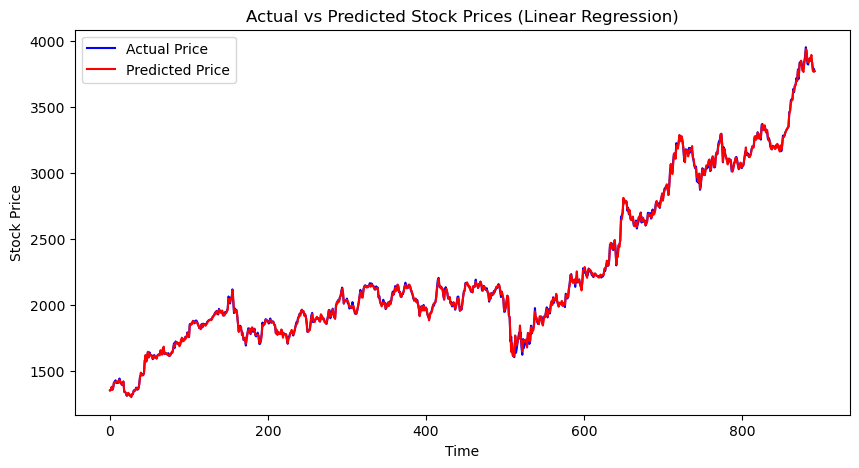

In [60]:
# Plot actual vs predicted prices
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred_lr, label='Predicted Price', color='red')

plt.title("Actual vs Predicted Stock Prices (Linear Regression)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()
